In [25]:
import os
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr
from datetime import datetime
from io import StringIO

# ==========================================
# 1. CONFIGURATION
# ==========================================

# Base directory for local files
BASE_DIR = "/Users/guyjansen/Desktop/Asset class research - Recession "

# Yahoo Finance Tickers
YF_TICKERS = ["TIP", "IYR","^GSPC", "BTC-USD", "DX-Y.NYB"]

# FRED Series Mapping
FRED_SERIES = {
    "CHF_USD": "DEXSZUS",            # Swiss Franc
    "JPY_USD": "DEXJPUS",            # Yen
    "Corp_Yield": "BAMLC0A0CMEY",    # US Corporate Index Effective Yield
    "Treasury_30Y": "DGS30",         # Long-term Treasury yield
    "Treasury_1Y": "DGS1"            # Short-term Treasury yield
}

# FactSet Excel Files
FACTSET_FILES = {
    "Oil": "Oil_PriceHistory_FACTSET.xlsx",
    "Gold": "Gold_PriceHistory_FACTSET.xlsx",
    "GSCI": "S&PGSCI_Comm_PriceHistory.xlsx",
}

# Fama-French CSV Files
FF_FILES = {
    "Value":     "VALUE_Portfolios_Formed_on_BE-ME.csv",
    "Quality":   "QUALITY_Portfolios_Formed_on_OP.csv",
    "Low_Vol":   "LOW_VOL_Portfolios_Formed_on_VAR.csv",
    "Small_Cap": "SMALL_CAP_Portfolios_Formed_on_ME.csv",
}

# Standard CSV Files
CSV_FILES = {
    "SG_CTA": "glued_cta_dbmf_track_record.csv"
}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def load_standard_csv(file_path):
    """
    Loads a standard CSV file. Assumes the first column is a date index, 
    or that there is a column explicitly named 'Date'.
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        return pd.DataFrame()
        
    try:
        # Load CSV and attempt to parse dates
        df = pd.read_csv(file_path)
        
        # Check if 'Date' exists in columns
        if 'Date' in df.columns or 'date' in df.columns:
            date_col = 'Date' if 'Date' in df.columns else 'date'
            df[date_col] = pd.to_datetime(df[date_col])
            df.set_index(date_col, inplace=True)
        else:
            # Fallback: Assume first column is the datetime index
            df = pd.read_csv(file_path, index_col=0, parse_dates=True)
            
        return df
    except Exception as e:
        print(f"Error loading CSV file {file_path}: {e}")
        return pd.DataFrame()

def load_factset_dynamic(file_path):
    """
    Scans the first 10 rows of an Excel file to find the header row containing 'Date',
    then loads the data setting 'Date' as the index.
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        return pd.DataFrame()

    try:
        # Preview first 10 rows to find header
        preview = pd.read_excel(file_path, header=None, nrows=10)
        
        header_row = None
        for i, row in preview.iterrows():
            if row.astype(str).str.contains('Date', case=False).any():
                header_row = i
                break
        
        if header_row is None:
            raise ValueError(f"Could not find 'Date' column in header of {file_path}")
        
        # Load actual data
        df = pd.read_excel(file_path, header=header_row, parse_dates=['Date'])
        df.set_index('Date', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading FactSet file {file_path}: {e}")
        return pd.DataFrame()

def parse_fama_french(file_path):
    """
    Parses Fama-French CSVs to extract the 'Value Weight Returns -- Monthly' block.
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}")
        return pd.DataFrame()

    try:
        with open(file_path, "r", encoding="utf-8", errors="replace") as f:
            raw_lines = [line.rstrip("\r\n") for line in f]

        # Helper to identify the start of the monthly value-weight section
        def is_header(line):
            l = line.lower().replace("–", "--")
            return (("value" in l or "vw" in l) and 
                    ("weight" in l or "value-weight" in l) and 
                    "monthly" in l)

        # Find start index
        start = next((i for i, l in enumerate(raw_lines) if is_header(l)), None)

        if start is None:
            # Fallback strategy: find first non-digit line
            start = next(i for i, l in enumerate(raw_lines) if l.strip() and not l.strip()[0].isdigit())

        # Find end index (next empty line or new block)
        end = next(
            (i for i, l in enumerate(raw_lines)
             if i > start + 1 and l.strip() and not l.strip()[0].isdigit() and not l.strip().startswith(",")),
            len(raw_lines)
        )

        # Extract block
        block = "\n".join(l for l in raw_lines[start + 1 : end] if l.strip())
        
        # Read to DataFrame
        df = pd.read_csv(StringIO(block), header=0, index_col=0, na_values=["-99.99", "-999"])
        df.index.name = "Date"
        
        # Clean Index (Format YYYYMM -> Datetime MonthEnd)
        df = df[pd.to_numeric(df.index, errors="coerce").notna()]
        df.index = pd.to_datetime(df.index.astype(int).astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
        df = df.astype(float)
        
        return df
    except Exception as e:
        print(f"Error parsing Fama-French file {file_path}: {e}")
        return pd.DataFrame()

# ==========================================
# 3. MAIN DATA LOADING
# ==========================================

def get_all_data():
    data_store = {}

    print("--- 1. Downloading Yahoo Finance Data ---")
    try:
        # Group download is faster
        yf_df = yf.download(YF_TICKERS, start="1970-01-01", progress=False)["Close"]
        # Store individual columns in data_store
        for col in yf_df.columns:
            data_store[col] = yf_df[[col]].dropna()
    except Exception as e:
        print(f"Yahoo Finance download failed: {e}")

    print("--- 2. Downloading FRED Data ---")
    try:
        fred_df = pdr.DataReader(list(FRED_SERIES.values()), "fred", start="1970-01-01", end=datetime.today())
        fred_df.rename(columns={v: k for k, v in FRED_SERIES.items()}, inplace=True)
        for col in fred_df.columns:
            data_store[col] = fred_df[[col]].dropna()
    except Exception as e:
        print(f"FRED download failed: {e}")

    print("--- 3. Loading FactSet Local Files ---")
    for name, filename in FACTSET_FILES.items():
        path = os.path.join(BASE_DIR, filename)
        df = load_factset_dynamic(path)
        if not df.empty:
            data_store[f"FactSet_{name}"] = df

    print("--- 4. Loading Fama-French Local Files ---")
    for name, filename in FF_FILES.items():
        path = os.path.join(BASE_DIR, filename)
        df = parse_fama_french(path)
        if not df.empty:
            data_store[f"FF_{name}"] = df
            
    print("--- 5. Loading Standard CSV Files ---")
    for name, filename in CSV_FILES.items():
        path = os.path.join(BASE_DIR, filename)
        df = load_standard_csv(path)
        if not df.empty:
            data_store[f"CSV_{name}"] = df

    return data_store

# ==========================================
# 4. EXECUTION AND SUMMARY
# ==========================================

if __name__ == "__main__":
    # Load all data
    all_data = get_all_data()

    print("\n" + "="*60)
    print(f"{'ASSET / SERIES':<25} | {'START DATE':<12} | {'SHAPE':<10}")
    print("="*60)

    # Sort keys for cleaner output
    for key in sorted(all_data.keys()):
        df = all_data[key]
        if not df.empty:
            start_date = df.index.min().strftime('%Y-%m-%d')
            shape_str = str(df.shape)
            print(f"{key:<25} | {start_date:<12} | {shape_str:<10}")
        else:
            print(f"{key:<25} | {'EMPTY':<12} | {str(df.shape):<10}")
    print("="*60)

# ==========================================
# 5. PROCESS FAMA-FRENCH PORTFOLIOS
# ==========================================

# Configuration for extraction
# Format: { 'Key_In_All_Data': ('Target_Column', 'New_Name', 'Description') }
ff_config = {
    "FF_Quality":   ("Hi 10", "Factor_Quality",   "High Operating Profitability (Top 10%)"),
    "FF_Low_Vol":   ("Lo 10", "Factor_LowVol",    "Low Variance (Bottom 10%)"),
    "FF_Value":     ("Hi 10", "Factor_Value",     "High Book-to-Market (Top 10%)"),
    "FF_Small_Cap": ("Lo 10", "Factor_SmallCap",  "Small Market Cap (Bottom 10%)")
}

print("--- Processing Fama-French Portfolios ---")

for key, (target_col, new_name, desc) in ff_config.items():
    if key in all_data and not all_data[key].empty:
        df = all_data[key].copy()
        
        # 1. Strip whitespace from column headers (FF CSVs often have spaces like " Hi 10 ")
        df.columns = df.columns.str.strip()
        
        # 2. Check if target column exists
        if target_col in df.columns:
            # Extract the specific series
            series = df[[target_col]].copy()
            
            # 3. Convert from Percentage (5.00) to Decimal (0.05)
            # Fama-French data is usually usually raw percentages
            series = series / 100.0
            
            # 4. Rename column
            series.columns = [new_name]
            
            # 5. Update the main dictionary
            # We replace the raw multi-column DF with the specific cleaned series
            all_data[key] = series
            
            print(f"SUCCESS: Extracted '{target_col}' from {key}")
            print(f"         -> Renamed to '{new_name}' ({desc})")
            print(f"         -> Range: {series.index.min().date()} to {series.index.max().date()}")
            print(f"         -> Sample val (Decimal): {series.iloc[0,0]:.4f}\n")
            
        else:
            print(f"ERROR: Column '{target_col}' not found in {key}.")
            print(f"       Available columns: {list(df.columns)}\n")
    else:
        print(f"WARNING: {key} is missing or empty in all_data.\n")

# ==========================================
# CHECK: Verify the change
# ==========================================
print("--- Updated Fama-French Data Check ---")
for key in ff_config.keys():
    if key in all_data:
        print(f"{key}:")
        print(all_data[key].tail(3)) # Show last 3 rows
        print("-" * 30)

--- 1. Downloading Yahoo Finance Data ---


/var/folders/wz/8tgpjswj4fg0909bddvzc2500000gn/T/ipykernel_91991/4127495954.py:168: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf_df = yf.download(YF_TICKERS, start="1970-01-01", progress=False)["Close"]


--- 2. Downloading FRED Data ---
--- 3. Loading FactSet Local Files ---
--- 4. Loading Fama-French Local Files ---
--- 5. Loading Standard CSV Files ---

ASSET / SERIES            | START DATE   | SHAPE     
BTC-USD                   | 2014-09-17   | (4192, 1) 
CHF_USD                   | 1971-01-04   | (13830, 1)
CSV_SG_CTA                | 1999-12-31   | (316, 1)  
Corp_Yield                | 1996-12-31   | (7619, 1) 
DX-Y.NYB                  | 1971-01-04   | (14012, 1)
FF_Low_Vol                | 1963-07-31   | (751, 15) 
FF_Quality                | 1963-07-31   | (751, 18) 
FF_Small_Cap              | 1926-07-31   | (1195, 19)
FF_Value                  | 1926-07-31   | (1195, 19)
FactSet_GSCI              | 1991-12-31   | (8606, 1) 
FactSet_Gold              | 1975-01-06   | (12899, 1)
FactSet_Oil               | 1974-12-31   | (12902, 1)
IYR                       | 2000-06-19   | (6468, 1) 
JPY_USD                   | 1971-01-04   | (13824, 1)
TIP                       | 2003-12-

In [8]:
# Using modified duration approximation: ΔP/P ≈ -Duration × ΔYield
# 30Y Treasury duration ≈ 18, 1Y Treasury duration ≈ 0.97, Corp IG duration ≈ 8

def yield_to_price_return(yield_series, duration):
    """
    Converts a yield series to approximate cumulative price return over each window.
    ΔP/P ≈ -Duration × Δyield  (yield in %, so divide by 100)
    """
    daily_ret = -duration * yield_series.diff() / 100
    return daily_ret  # daily price-return approximation as a series

treasury_30y_ret = yield_to_price_return(all_data["Treasury_30Y"].iloc[:, 0], duration=18.0)
treasury_1y_ret  = yield_to_price_return(all_data["Treasury_1Y"].iloc[:, 0],  duration=0.97)
corp_yield_ret   = yield_to_price_return(all_data["Corp_Yield"].iloc[:, 0],   duration=8.0)

YIELD_ASSETS = {
    "Treasury 30Y": treasury_30y_ret,
    "Treasury 1Y":  treasury_1y_ret,
    "Corp Bond":    corp_yield_ret,
}

# ---- 2. FACTSET PRICE ASSETS (Gold, Oil, GSCI) ----
# These are loaded as all_data["FactSet_Gold"] etc.
# Extract the first numeric price column from each

def extract_factset_price(key):
    if key not in all_data or all_data[key].empty:
        print(f"WARNING: {key} not found or empty.")
        return pd.Series(dtype=float)
    df = all_data[key].copy()
    # Drop non-numeric columns, take first remaining column
    df = df.select_dtypes(include=[np.number])
    if df.empty:
        return pd.Series(dtype=float)
    return df.iloc[:, 0].dropna()

FACTSET_PRICE_ASSETS = {
    "Gold":  extract_factset_price("FactSet_Gold"),
    "Oil":   extract_factset_price("FactSet_Oil"),
    "GSCI":  extract_factset_price("FactSet_GSCI"),
}

# ---- 3. CSV ASSETS (CTA — Managed Futures) ----
# CTA index is typically monthly return data (already in % or decimal)
def extract_csv_returns(key):
    if key not in all_data or all_data[key].empty:
        print(f"WARNING: {key} not found or empty.")
        return pd.Series(dtype=float)
    df = all_data[key].copy()
    df = df.select_dtypes(include=[np.number])
    if df.empty:
        return pd.Series(dtype=float)
    series = df.iloc[:, 0].dropna()
    # Detect if values look like percentages (e.g. 5.2 instead of 0.052)
    if series.abs().mean() > 1.0:
        series = series / 100.0
    return series

SG_CTA = extract_csv_returns("CSV_SG_CTA")



BEAR MARKET PERFORMANCE — TOTAL RETURN PER PERIOD
Bear Market                               S&P 500US Real Estate (IYR)             TIPS        USD Index          CHF/USD          JPY/USD          Bitcoin     Treasury 30Y      Treasury 1Y        Corp Bond             Gold              Oil             GSCI  Managed Futures     Quality (FF)     Low Vol (FF)       Value (FF)   Small Cap (FF)
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1973–74 Oil Crisis (630d)                  -48.2%              N/A              N/A            -7.1%           -21.8%            -0.8%              N/A              N/A            -2.6%              N/A              N/A              N/A              N/A            

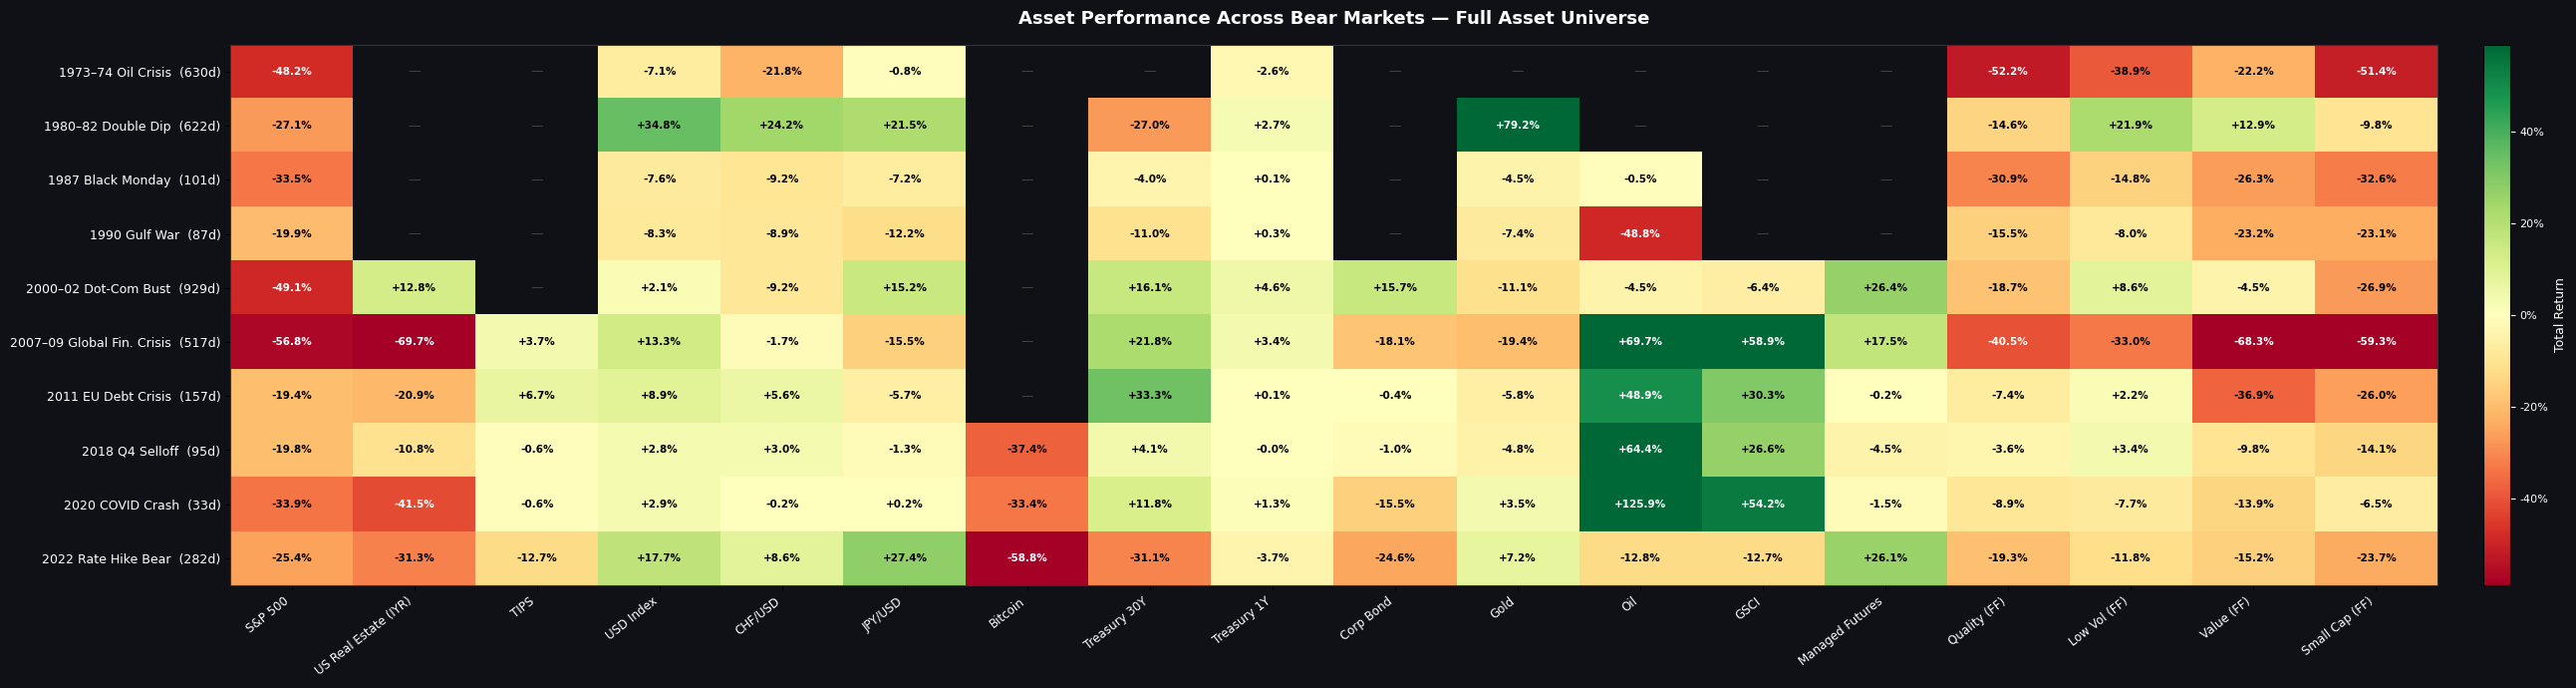

Saved: bear_market_heatmap_full.png

BULL MARKET PERFORMANCE — TOTAL RETURN PER PERIOD
Bull Market                                     S&P 500US Real Estate (IYR)             TIPS        USD Index          CHF/USD          JPY/USD          Bitcoin     Treasury 30Y      Treasury 1Y        Corp Bond             Gold              Oil             GSCI  Managed Futures     Quality (FF)     Low Vol (FF)       Value (FF)   Small Cap (FF)
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Bull 19: 1970-05-26 / 1973-01-11  (961d)           +73.5%              N/A              N/A            -8.6%           -12.9%           -15.7%              N/A              N/A            +2.1%              N/A       

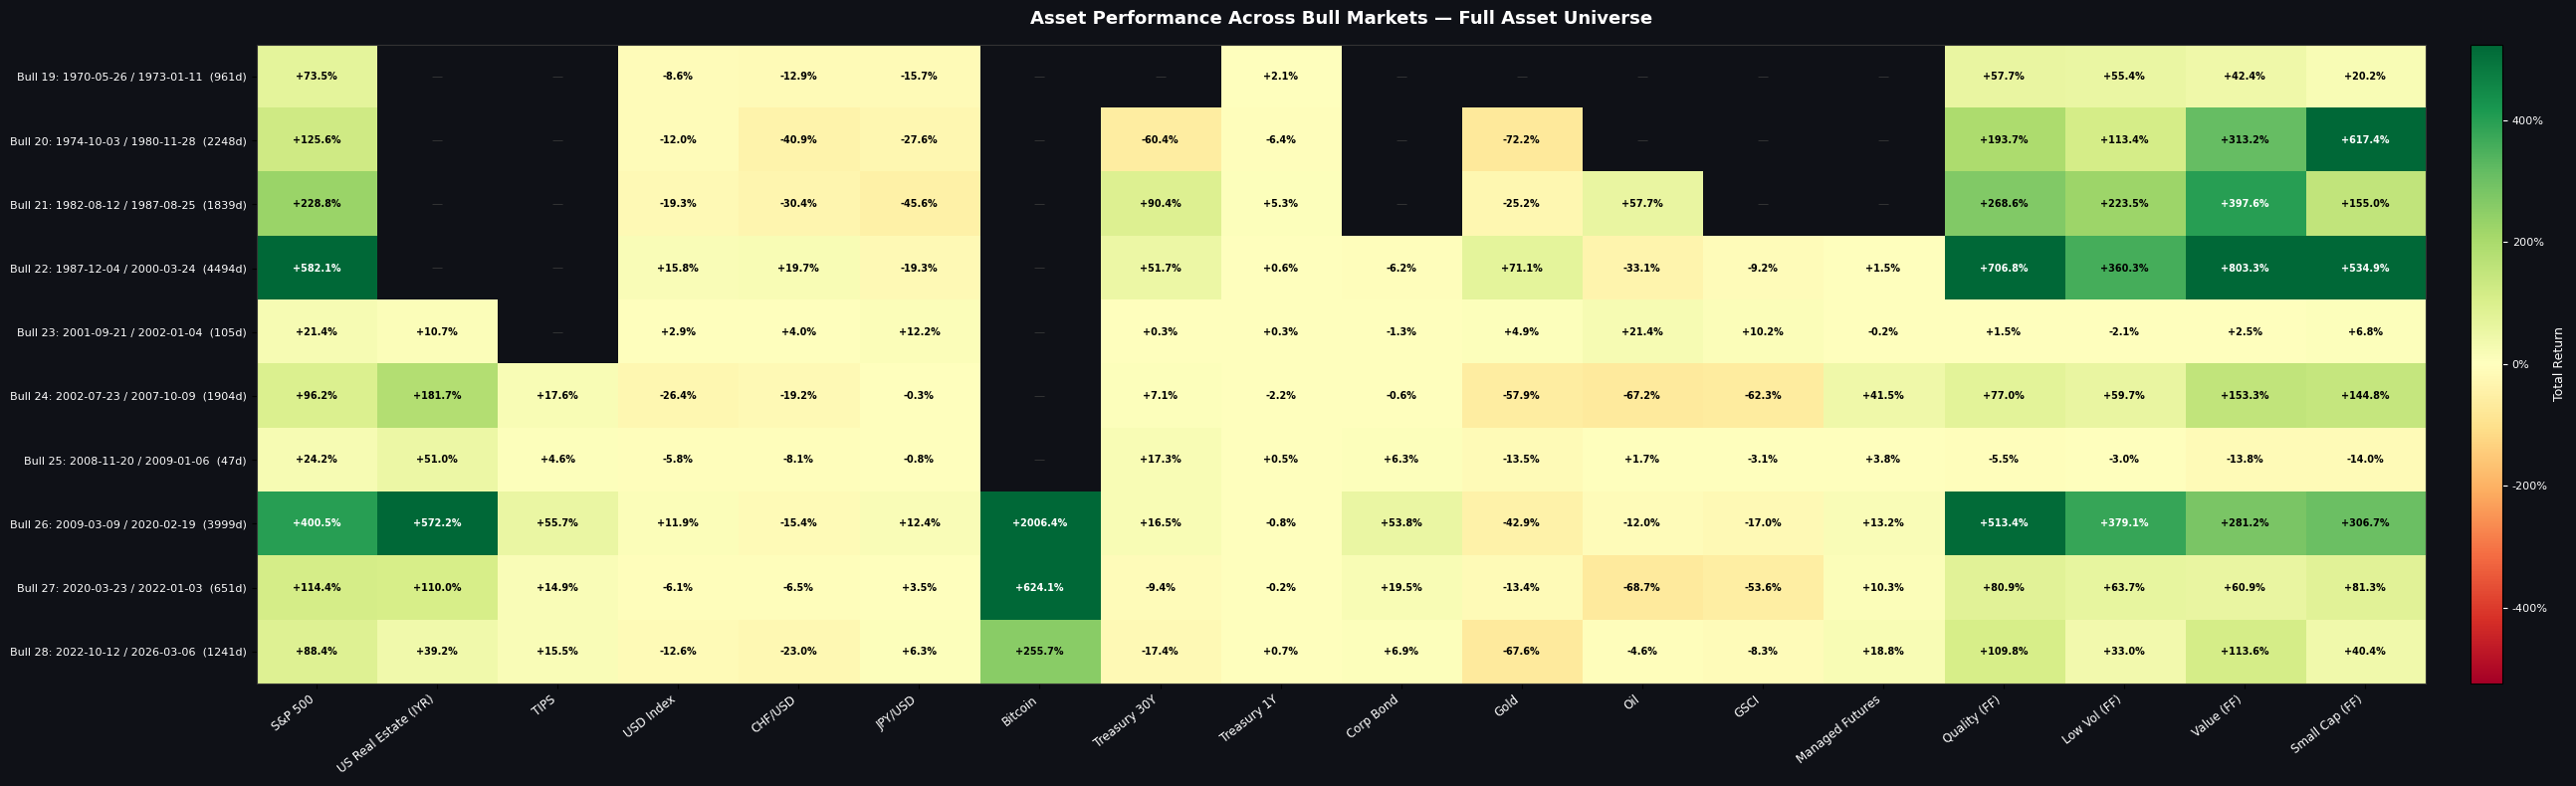

Saved: bull_market_heatmap_full.png


In [27]:
# ==========================================
# BEAR MARKET ANALYSIS — EXTENDED ASSET SET
# ==========================================

BEAR_MARKETS = {
    "1973–74 Oil Crisis":         ("1973-01-11", "1974-10-03"),
    "1980–82 Double Dip":         ("1980-11-28", "1982-08-12"),
    "1987 Black Monday":          ("1987-08-25", "1987-12-04"),
    "1990 Gulf War":              ("1990-07-16", "1990-10-11"),
    "2000–02 Dot-Com Bust":       ("2000-03-24", "2002-10-09"),
    "2007–09 Global Fin. Crisis": ("2007-10-09", "2009-03-09"),
    "2011 EU Debt Crisis":        ("2011-04-29", "2011-10-03"),
    "2018 Q4 Selloff":            ("2018-09-20", "2018-12-24"),
    "2020 COVID Crash":           ("2020-02-19", "2020-03-23"),
    "2022 Rate Hike Bear":        ("2022-01-03", "2022-10-12"),
}

# ---- 1. YIELD → APPROXIMATE PRICE RETURN ----
# Using modified duration approximation: ΔP/P ≈ -Duration × ΔYield
# 30Y Treasury duration ≈ 18, 1Y Treasury duration ≈ 0.97, Corp IG duration ≈ 8

def yield_to_price_return(yield_series, duration):
    """
    Converts a yield series to approximate cumulative price return over each window.
    ΔP/P ≈ -Duration × Δyield  (yield in %, so divide by 100)
    """
    daily_ret = -duration * yield_series.diff() / 100
    return daily_ret  # daily price-return approximation as a series

treasury_30y_ret = yield_to_price_return(all_data["Treasury_30Y"].iloc[:, 0], duration=18.0)
treasury_1y_ret  = yield_to_price_return(all_data["Treasury_1Y"].iloc[:, 0],  duration=0.97)
corp_yield_ret   = yield_to_price_return(all_data["Corp_Yield"].iloc[:, 0],   duration=8.0)

YIELD_ASSETS = {
    "Treasury 30Y": treasury_30y_ret,
    "Treasury 1Y":  treasury_1y_ret,
    "Corp Bond":    corp_yield_ret,
}

# ---- 2. FACTSET PRICE ASSETS (Gold, Oil, GSCI) ----
# These are loaded as all_data["FactSet_Gold"] etc.
# Extract the first numeric price column from each

def extract_factset_price(key):
    if key not in all_data or all_data[key].empty:
        print(f"WARNING: {key} not found or empty.")
        return pd.Series(dtype=float)
    df = all_data[key].copy()
    # Drop non-numeric columns, take first remaining column
    df = df.select_dtypes(include=[np.number])
    if df.empty:
        return pd.Series(dtype=float)
    return df.iloc[:, 0].dropna()

FACTSET_PRICE_ASSETS = {
    "Gold":  extract_factset_price("FactSet_Gold"),
    "Oil":   extract_factset_price("FactSet_Oil"),
    "GSCI":  extract_factset_price("FactSet_GSCI"),
}

# ---- 3. CSV ASSETS ( CTA — Managed Futures) ----
#  CTA index is typically monthly return data (already in % or decimal)
def extract_csv_returns(key):
    if key not in all_data or all_data[key].empty:
        print(f"WARNING: {key} not found or empty.")
        return pd.Series(dtype=float)
    df = all_data[key].copy()
    df = df.select_dtypes(include=[np.number])
    if df.empty:
        return pd.Series(dtype=float)
    series = df.iloc[:, 0].dropna()
    # Detect if values look like percentages (e.g. 5.2 instead of 0.052)
    if series.abs().mean() > 1.0:
        series = series / 100.0
    return series

SG_CTA = extract_csv_returns("CSV_SG_CTA")

# ---- 4. PERIOD RETURN HELPERS ----

def period_return_price(series, start_str, end_str):
    """Total return from price series over [start, end]."""
    start, end = pd.Timestamp(start_str), pd.Timestamp(end_str)
    if series.empty or series.index.min() > end or series.index.max() < start:
        return np.nan
    window = series[(series.index >= start) & (series.index <= end)]
    if len(window) < 2:
        return np.nan
    return (window.iloc[-1] / window.iloc[0]) - 1

def period_return_daily_ret(series, start_str, end_str):
    """Cumulative return from a daily-return series (e.g. yield-derived)."""
    start, end = pd.Timestamp(start_str), pd.Timestamp(end_str)
    if series.empty or series.index.min() > end or series.index.max() < start:
        return np.nan
    window = series[(series.index >= start) & (series.index <= end)].dropna()
    if window.empty:
        return np.nan
    return (1 + window).prod() - 1

def period_return_monthly_ret(series, start_str, end_str):
    """Cumulative return from a monthly-return series."""
    start, end = pd.Timestamp(start_str), pd.Timestamp(end_str)
    if series.empty or series.index.min() > end or series.index.max() < start:
        return np.nan
    window = series[(series.index >= start) & (series.index <= end)].dropna()
    if window.empty:
        return np.nan
    return (1 + window).prod() - 1

# ---- 5. BUILD FULL RESULTS MATRIX ----

PRICE_ASSETS_DAILY = {
    "S&P 500":              "^GSPC",
    "US Real Estate (IYR)": "IYR",
    "TIPS":                 "TIP",
    "USD Index":            "DX-Y.NYB",
    "CHF/USD":              "CHF_USD",
    "JPY/USD":              "JPY_USD",
    "Bitcoin":              "BTC-USD",
}

FF_ASSETS_MONTHLY = {
    "Quality (FF)":   "FF_Quality",
    "Low Vol (FF)":   "FF_Low_Vol",
    "Value (FF)":     "FF_Value",
    "Small Cap (FF)": "FF_Small_Cap",
}

results = {}

for bear_name, (start, end) in BEAR_MARKETS.items():
    row = {}

    # A. Yahoo Finance price assets
    for label, store_key in PRICE_ASSETS_DAILY.items():
        if store_key in all_data and not all_data[store_key].empty:
            row[label] = period_return_price(all_data[store_key].iloc[:, 0], start, end)
        else:
            row[label] = np.nan

    # B. Yield-derived return assets
    for label, ret_series in YIELD_ASSETS.items():
        row[label] = period_return_daily_ret(ret_series, start, end)

    # C. FactSet price assets
    for label, price_series in FACTSET_PRICE_ASSETS.items():
        row[label] = period_return_price(price_series, start, end)

    # D. CTA (monthly returns)
    row["Managed Futures"] = period_return_monthly_ret(SG_CTA, start, end)

    # E. FF assets (monthly returns)
    for label, store_key in FF_ASSETS_MONTHLY.items():
        if store_key in all_data and not all_data[store_key].empty:
            row[label] = period_return_monthly_ret(all_data[store_key].iloc[:, 0], start, end)
        else:
            row[label] = np.nan

    results[bear_name] = row

bear_df = pd.DataFrame(results).T
bear_df = bear_df.dropna(axis=1, how="all")

# ---- 6. PRINT TABLE ----

print("\n" + "=" * 140)
print("BEAR MARKET PERFORMANCE — TOTAL RETURN PER PERIOD")
print("=" * 140)

col_w = 17
header = f"{'Bear Market':<32}" + "".join(f"{col:>{col_w}}" for col in bear_df.columns)
print(header)
print("-" * len(header))

for bear_name, row in bear_df.iterrows():
    s, e   = BEAR_MARKETS[bear_name]
    dur    = (pd.Timestamp(e) - pd.Timestamp(s)).days
    label  = f"{bear_name} ({dur}d)"
    line   = f"{label:<32}"
    for col in bear_df.columns:
        val  = row[col]
        cell = f"{val:+.1%}" if not pd.isna(val) else "N/A"
        line += f"{cell:>{col_w}}"
    print(line)

print("=" * 140)

# ---- 7. HEATMAP ----

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(26, 7), facecolor="#0f1117")
ax.set_facecolor("#0f1117")

data_vals = bear_df.values.astype(float)
vmax      = np.nanpercentile(np.abs(data_vals), 95)
norm      = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap      = plt.cm.RdYlGn

ax.imshow(data_vals, aspect="auto", cmap=cmap, norm=norm)

ax.set_xticks(range(len(bear_df.columns)))
ax.set_xticklabels(bear_df.columns, rotation=38, ha="right", color="white", fontsize=8.5)

bear_labels = [
    f"{n}  ({(pd.Timestamp(BEAR_MARKETS[n][1]) - pd.Timestamp(BEAR_MARKETS[n][0])).days}d)"
    for n in bear_df.index
]
ax.set_yticks(range(len(bear_df.index)))
ax.set_yticklabels(bear_labels, color="white", fontsize=9)

for i in range(len(bear_df.index)):
    for j in range(len(bear_df.columns)):
        val = data_vals[i, j]
        if not np.isnan(val):
            txt   = f"{val:+.1%}"
            bg    = plt.cm.RdYlGn(norm(val))
            lum   = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
            tcolor = "black" if lum > 0.5 else "white"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7.5, color=tcolor, fontweight="bold")
        else:
            ax.text(j, i, "—", ha="center", va="center",
                    fontsize=9, color="#444444")

cbar = fig.colorbar(ax.images[0], ax=ax, fraction=0.015, pad=0.02)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
cbar.ax.tick_params(colors="white", labelsize=8)
cbar.ax.set_ylabel("Total Return", color="white", fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Asset Performance Across Bear Markets — Full Asset Universe",
             color="white", fontsize=13, fontweight="bold", pad=15)
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("bear_market_heatmap_full.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: bear_market_heatmap_full.png")

# ==========================================
# BULL MARKET PERIOD ANALYSIS
# ==========================================

BULL_MARKETS = {
    "Bull 19: 1970-05-26 / 1973-01-11": ("1970-05-26", "1973-01-11"),
    "Bull 20: 1974-10-03 / 1980-11-28": ("1974-10-03", "1980-11-28"),
    "Bull 21: 1982-08-12 / 1987-08-25": ("1982-08-12", "1987-08-25"),
    "Bull 22: 1987-12-04 / 2000-03-24": ("1987-12-04", "2000-03-24"),
    "Bull 23: 2001-09-21 / 2002-01-04": ("2001-09-21", "2002-01-04"),
    "Bull 24: 2002-07-23 / 2007-10-09": ("2002-07-23", "2007-10-09"),
    "Bull 25: 2008-11-20 / 2009-01-06": ("2008-11-20", "2009-01-06"),
    "Bull 26: 2009-03-09 / 2020-02-19": ("2009-03-09", "2020-02-19"),
    "Bull 27: 2020-03-23 / 2022-01-03": ("2020-03-23", "2022-01-03"),
    "Bull 28: 2022-10-12 / 2026-03-06": ("2022-10-12", "2026-03-06"),
}

# ---- BUILD RESULTS MATRIX (reusing all helper functions from bear market code) ----

results_bull = {}

for bull_name, (start, end) in BULL_MARKETS.items():
    row = {}

    # A. Yahoo Finance price assets
    for label, store_key in PRICE_ASSETS_DAILY.items():
        if store_key in all_data and not all_data[store_key].empty:
            row[label] = period_return_price(all_data[store_key].iloc[:, 0], start, end)
        else:
            row[label] = np.nan

    # B. Yield-derived return assets
    for label, ret_series in YIELD_ASSETS.items():
        row[label] = period_return_daily_ret(ret_series, start, end)

    # C. FactSet price assets
    for label, price_series in FACTSET_PRICE_ASSETS.items():
        row[label] = period_return_price(price_series, start, end)

    # D.  CTA (monthly returns)
    row["Managed Futures"] = period_return_monthly_ret(SG_CTA, start, end)

    # E. FF assets (monthly returns)
    for label, store_key in FF_ASSETS_MONTHLY.items():
        if store_key in all_data and not all_data[store_key].empty:
            row[label] = period_return_monthly_ret(all_data[store_key].iloc[:, 0], start, end)
        else:
            row[label] = np.nan

    results_bull[bull_name] = row

bull_df = pd.DataFrame(results_bull).T
bull_df = bull_df.dropna(axis=1, how="all")

# ---- PRINT TABLE ----

print("\n" + "=" * 140)
print("BULL MARKET PERFORMANCE — TOTAL RETURN PER PERIOD")
print("=" * 140)

col_w  = 17
header = f"{'Bull Market':<38}" + "".join(f"{col:>{col_w}}" for col in bull_df.columns)
print(header)
print("-" * len(header))

for bull_name, row in bull_df.iterrows():
    s, e  = BULL_MARKETS[bull_name]
    dur   = (pd.Timestamp(e) - pd.Timestamp(s)).days
    label = f"{bull_name}  ({dur}d)"
    line  = f"{label:<38}"
    for col in bull_df.columns:
        val  = row[col]
        cell = f"{val:+.1%}" if not pd.isna(val) else "N/A"
        line += f"{cell:>{col_w}}"
    print(line)

print("=" * 140)

# ---- HEATMAP ----

# Split into two figures (early pre-data vs modern) to keep it readable
split_idx = 22  # Bulls 1–22 are mostly pre-data; 23–28 have full coverage

for chunk_label, chunk_df in [("All Periods", bull_df), ]:
    n_rows = len(chunk_df)
    fig_h  = max(8, n_rows * 0.52)
    fig, ax = plt.subplots(figsize=(26, fig_h), facecolor="#0f1117")
    ax.set_facecolor("#0f1117")

    data_vals = chunk_df.values.astype(float)
    vmax      = np.nanpercentile(np.abs(data_vals[~np.isnan(data_vals)]), 95) if not np.all(np.isnan(data_vals)) else 1.0
    norm      = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap      = plt.cm.RdYlGn

    im = ax.imshow(data_vals, aspect="auto", cmap=cmap, norm=norm)

    ax.set_xticks(range(len(chunk_df.columns)))
    ax.set_xticklabels(chunk_df.columns, rotation=38, ha="right", color="white", fontsize=8.5)

    bull_ylabels = [
        f"{n}  ({(pd.Timestamp(BULL_MARKETS[n][1]) - pd.Timestamp(BULL_MARKETS[n][0])).days}d)"
        for n in chunk_df.index
    ]
    ax.set_yticks(range(len(chunk_df.index)))
    ax.set_yticklabels(bull_ylabels, color="white", fontsize=8)

    for i in range(len(chunk_df.index)):
        for j in range(len(chunk_df.columns)):
            val = data_vals[i, j]
            if not np.isnan(val):
                txt    = f"{val:+.1%}"
                bg     = plt.cm.RdYlGn(norm(val))
                lum    = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
                tcolor = "black" if lum > 0.5 else "white"
                ax.text(j, i, txt, ha="center", va="center",
                        fontsize=7, color=tcolor, fontweight="bold")
            else:
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=8, color="#3a3a3a")

    cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.02)
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.ax.set_ylabel("Total Return", color="white", fontsize=9)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    ax.set_title("Asset Performance Across Bull Markets — Full Asset Universe",
                 color="white", fontsize=13, fontweight="bold", pad=15)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

    plt.tight_layout()
    plt.savefig("bull_market_heatmap_full.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved: bull_market_heatmap_full.png")

In [63]:
# In[ ]:


# ==========================================
# 6. THOROUGH PERFORMANCE ANALYSIS (CORRECTED)
# ==========================================
import numpy as np
import pandas as pd
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

print("--- Compiling Unified Monthly Returns Dataset ---")

monthly_returns_dict = {}

# 1. PRICE_ASSETS_DAILY (Yahoo Finance)
for label, store_key in PRICE_ASSETS_DAILY.items():
    if store_key in all_data and not all_data[store_key].empty:
        s = all_data[store_key].iloc[:, 0].dropna()
        monthly_returns_dict[label] = s.resample('ME').last().pct_change()

# 2. YIELD_ASSETS (Daily approximate returns based on duration)
for label, ret_series in YIELD_ASSETS.items():
    s = ret_series.dropna()
    monthly_returns_dict[label] = s.resample('ME').apply(lambda x: (1+x).prod() - 1)

# 3. FACTSET_PRICE_ASSETS
for label, price_series in FACTSET_PRICE_ASSETS.items():
    s = price_series.dropna()
    monthly_returns_dict[label] = s.resample('ME').last().pct_change()

# 4. CSV (Monthly Returns)
if SG_CTA is not None and not SG_CTA.empty:
    s = SG_CTA.copy()
    s.index = pd.to_datetime(s.index) + pd.offsets.MonthEnd(0)
    monthly_returns_dict["Managed Futures"] = s.groupby(s.index).last()

# 5. Fama-French (Monthly Returns)
for label, store_key in FF_ASSETS_MONTHLY.items():
    if store_key in all_data and not all_data[store_key].empty:
        s = all_data[store_key].iloc[:, 0].dropna()
        s.index = pd.to_datetime(s.index) + pd.offsets.MonthEnd(0)
        monthly_returns_dict[label] = s.groupby(s.index).last()

df_monthly = pd.DataFrame(monthly_returns_dict)
df_ym = df_monthly.index.to_period('M')

# Regime Masks
bear_mask = pd.Series(False, index=df_monthly.index)
for b_name, (start, end) in BEAR_MARKETS.items():
    bear_mask |= (df_ym >= pd.Timestamp(start).to_period('M')) & (df_ym <= pd.Timestamp(end).to_period('M'))

bull_mask = pd.Series(False, index=df_monthly.index)
for b_name, (start, end) in BULL_MARKETS.items():
    bull_mask |= (df_ym >= pd.Timestamp(start).to_period('M')) & (df_ym <= pd.Timestamp(end).to_period('M'))

sp500_monthly = df_monthly['S&P 500']

# ==========================================
# CALCULATE ADVANCED METRICS
# ==========================================
print("--- Calculating Analytics per Asset ---")

results_metrics = {}

for col in df_monthly.columns:
    asset = df_monthly[col]
    a_all  = asset.dropna()
    a_bear = asset[bear_mask].dropna()
    a_bull = asset[bull_mask].dropna()
    
    sp_all  = sp500_monthly.loc[a_all.index]
    sp_bear = sp500_monthly.loc[a_bear.index]
    sp_bull = sp500_monthly.loc[a_bull.index]
    
    if a_all.empty: 
        continue
    
    # 1. Base Metrics
    avg_ret, vol_ret   = a_all.mean(), a_all.std()
    bear_ret, bear_vol = a_bear.mean(), a_bear.std()
    bull_ret, bull_vol = a_bull.mean(), a_bull.std()
    
    # 2. Relative & Capture Metrics
    bear_excess = bear_ret - sp_bear.mean()
    down_cap = (bear_ret / sp_bear.mean()) if sp_bear.mean() != 0 else np.nan
    up_cap   = (bull_ret / sp_bull.mean()) if sp_bull.mean() != 0 else np.nan
    
    # 3. True Absolute Max Drawdown (All-Time)
    cum_all = (1 + a_all).cumprod()
    abs_mdd = ((cum_all / cum_all.cummax()) - 1).min()
    
    # 4. Bear Market Drawdown & Time to Recover (Fixed Logic)
    mdd_list, rec_list = [],[]
    idx_series = (1 + a_all).cumprod() # Continuous value index
    
    for b_name, (start, end) in BEAR_MARKETS.items():
        s_date, e_date = pd.Timestamp(start), pd.Timestamp(end)
        
        # Check if asset actually existed during this bear market
        window_idx = idx_series.loc[s_date:e_date]
        if window_idx.empty:
            continue # Skip phantom data
            
        # Drawdown specifically within the bear window
        window_mdd = (window_idx / window_idx.cummax()) - 1
        min_dd = window_mdd.min()
        mdd_list.append(min_dd)
        
        # Recovery calculation
        if min_dd < 0:
            trough_date = window_mdd.idxmin()
            peak_date = window_idx.loc[:trough_date].idxmax()
            peak_val = window_idx.loc[peak_date]
            
            # Look forward from trough
            forward_idx = idx_series.loc[trough_date:]
            recovered = forward_idx >= peak_val
            
            if recovered.any():
                rec_date = recovered.idxmax()
                # Peak-to-Recovery time
                months = (rec_date.year - peak_date.year)*12 + (rec_date.month - peak_date.month)
                rec_list.append(months)
                
    avg_mdd_bear   = np.nanmean(mdd_list) if mdd_list else np.nan
    avg_rec_months = np.nanmean(rec_list) if rec_list else np.nan
    
    # 5. Statistical Distributions & Betas
    corr_all  = a_all.corr(sp_all)
    corr_bear = a_bear.corr(sp_bear)
    corr_bull = a_bull.corr(sp_bull)
    skew_bear = a_bear.skew()
    
    # Tail Beta
    q10 = sp500_monthly.quantile(0.10)
    a_tail = asset[sp500_monthly <= q10].dropna()
    sp_tail = sp500_monthly.loc[a_tail.index]
    tail_beta = a_tail.cov(sp_tail) / sp_tail.var() if len(a_tail) > 1 and sp_tail.var() > 0 else np.nan
        
    # Crisis Alpha
    crisis_alpha = bear_ret - ((a_bear.cov(sp_bear) / sp_bear.var()) * sp_bear.mean()) if len(a_bear) > 1 and sp_bear.var() > 0 else np.nan
        
    # Crisis Consistency Score
    consistency = (bear_df[col] > 0).sum() / bear_df[col].notna().sum() if col in bear_df.columns and bear_df[col].notna().sum() > 0 else np.nan
        
    # Bear Market Sharpe (Ann)
    bear_sharpe = (bear_ret / bear_vol) * np.sqrt(12) if bear_vol > 0 else np.nan
    
    # Timing Lag
    lags, corrs =[-2, -1, 0, 1, 2],[]
    for l in lags:
        comb = pd.concat([asset, sp500_monthly.shift(l)], axis=1).dropna()
        corrs.append(comb.iloc[:, 0].corr(comb.iloc[:, 1]) if len(comb) > 10 else 0)
    best_lag = lags[np.argmax(np.abs(corrs))] if corrs else np.nan
    
    # Drawdown Convexity
    df_temp = pd.DataFrame({'sp': sp_bear, 'a': a_bear}).dropna()
    convexity = np.polyfit(df_temp['sp'], df_temp['a'], 2)[0] if len(df_temp) > 2 and df_temp['sp'].var() > 0 else np.nan

    # Store Results
    results_metrics[col] = {
        "Avg Monthly Return": avg_ret,
        "Monthly Volatility": vol_ret,
        "Bear Avg Monthly Return": bear_ret,
        "Bear Monthly Volatility": bear_vol,
        "Bull Avg Monthly Return": bull_ret,
        "Bull Monthly Volatility": bull_vol,
        "Bear Excess Return": bear_excess,
        "Downside Capture": down_cap,
        "Upside Capture": up_cap,
        "Avg S&P-Aligned Bear MDD": avg_mdd_bear,
        "True Absolute Max Drawdown": abs_mdd,
        "Overall Correlation": corr_all,
        "Bear Correlation": corr_bear,
        "Bull Correlation": corr_bull,
        "Bear Skewness": skew_bear,
        "Tail Beta (10% SP)": tail_beta,
        "Crisis Alpha (Monthly)": crisis_alpha,
        "Avg Time to Recover (Months)": avg_rec_months,
        "Crisis Consistency Score": consistency,
        "Bear Market Sharpe (Ann)": bear_sharpe,
        "Timing Lag (Months)": best_lag,
        "Drawdown Convexity": convexity
    }

# ==========================================
# FORMAT AND RENDER RESULTS
# ==========================================

perf_df = pd.DataFrame(results_metrics).T

# Specific Column Order (Grouped logically)
cols_order =[
    "Avg Monthly Return", "Monthly Volatility", 
    "Bear Avg Monthly Return", "Bear Monthly Volatility", 
    "Bull Avg Monthly Return", "Bull Monthly Volatility",
    "Bear Excess Return", "Downside Capture", "Upside Capture",
    "Avg S&P-Aligned Bear MDD", "True Absolute Max Drawdown", 
    "Overall Correlation", "Bear Correlation", "Bull Correlation", 
    "Bear Skewness", "Tail Beta (10% SP)", "Crisis Alpha (Monthly)", 
    "Avg Time to Recover (Months)", "Crisis Consistency Score", 
    "Bear Market Sharpe (Ann)", "Timing Lag (Months)", "Drawdown Convexity"
]
perf_df = perf_df[cols_order]

format_dict = {
    "Avg Monthly Return": "{:.2%}", "Monthly Volatility": "{:.2%}",
    "Bear Avg Monthly Return": "{:.2%}", "Bear Monthly Volatility": "{:.2%}",
    "Bull Avg Monthly Return": "{:.2%}", "Bull Monthly Volatility": "{:.2%}",
    "Bear Excess Return": "{:.2%}", "Downside Capture": "{:.2f}", "Upside Capture": "{:.2f}",
    "Avg S&P-Aligned Bear MDD": "{:.2%}", "True Absolute Max Drawdown": "{:.2%}",
    "Overall Correlation": "{:.2f}", "Bear Correlation": "{:.2f}", "Bull Correlation": "{:.2f}",
    "Bear Skewness": "{:.2f}", "Tail Beta (10% SP)": "{:.2f}",
    "Crisis Alpha (Monthly)": "{:.2%}", "Avg Time to Recover (Months)": "{:.1f}",
    "Crisis Consistency Score": "{:.0%}", "Bear Market Sharpe (Ann)": "{:.2f}",
    "Timing Lag (Months)": "{:.0f}", "Drawdown Convexity": "{:.2f}"
}

# Beautiful styling mapped correctly to the new logic
styled_df = (perf_df.style
    .format(format_dict)
    .background_gradient(subset=["Bear Avg Monthly Return", "Crisis Consistency Score", "Crisis Alpha (Monthly)"], cmap="RdYlGn")
    .background_gradient(subset=["Avg S&P-Aligned Bear MDD", "True Absolute Max Drawdown", "Downside Capture", "Avg Time to Recover (Months)"], cmap="RdYlGn_r")
    .background_gradient(subset=["Overall Correlation", "Bear Correlation","Bull Correlation"], cmap="coolwarm")
    .set_caption("Advanced Asset Performance & Resilience Metrics")
    .set_table_styles([{
        'selector': 'caption',
        'props':[('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'left')]
    }])
)

perf_df.to_csv("asset_advanced_performance_metrics.csv")
print("Saved raw output to: asset_advanced_performance_metrics.csv")

display(styled_df)

--- Compiling Unified Monthly Returns Dataset ---
--- Calculating Analytics per Asset ---
Saved raw output to: asset_advanced_performance_metrics.csv


,Avg Monthly Return,Monthly Volatility,Bear Avg Monthly Return,Bear Monthly Volatility,Bull Avg Monthly Return,Bull Monthly Volatility,Bear Excess Return,Downside Capture,Upside Capture,Avg S&P-Aligned Bear MDD,True Absolute Max Drawdown,Overall Correlation,Bear Correlation,Bull Correlation,Bear Skewness,Tail Beta (10% SP),Crisis Alpha (Monthly),Avg Time to Recover (Months),Crisis Consistency Score,Bear Market Sharpe (Ann),Timing Lag (Months),Drawdown Convexity
S&P 500,0.75%,4.39%,-1.91%,5.96%,1.26%,4.02%,0.00%,1.00,1.00,-25.69%,-52.56%,1.00,1.00,1.00,0.09,1.00,0.00%,36.0,0%,-1.11,0,-0.00
US Real Estate (IYR),0.83%,5.75%,-1.89%,7.84%,1.16%,5.36%,0.48%,0.80,1.06,-19.86%,-69.70%,0.68,0.69,0.67,-1.15,2.07,0.27%,20.4,17%,-0.83,0,-5.27
TIPS,0.31%,1.65%,0.11%,2.89%,0.40%,1.42%,2.99%,-0.04,0.35,-5.23%,-13.91%,0.31,0.56,0.18,-0.36,0.61,0.86%,15.5,40%,0.13,0,-1.19
USD Index,-0.00%,2.41%,0.25%,2.79%,-0.07%,2.32%,2.16%,-0.13,-0.06,-5.36%,-55.24%,-0.16,-0.18,-0.15,-0.05,-0.05,0.09%,21.6,70%,0.31,0,-0.17
CHF/USD,-0.21%,3.24%,-0.27%,3.83%,-0.22%,3.17%,1.64%,0.14,-0.17,-9.91%,-82.15%,-0.04,-0.07,-0.06,-0.20,0.07,-0.35%,8.4,40%,-0.24,1,-0.48
JPY/USD,-0.08%,3.09%,0.04%,3.56%,-0.15%,2.97%,1.96%,-0.02,-0.12,-8.03%,-78.65%,0.01,-0.01,0.03,-0.34,0.15,0.04%,87.6,40%,0.04,2,-0.76
Bitcoin,5.79%,20.79%,-9.41%,15.71%,6.55%,20.76%,-6.08%,2.82,5.44,-32.23%,-75.57%,0.34,0.48,0.30,-0.20,2.61,-5.52%,15.5,0%,-2.07,0,7.09
Treasury 30Y,0.09%,5.43%,0.15%,7.17%,0.19%,5.18%,2.06%,-0.08,0.16,-15.17%,-78.68%,0.13,0.02,0.14,0.56,-0.54,0.19%,25.9,56%,0.07,0,2.17
Treasury 1Y,0.01%,0.47%,0.05%,0.66%,0.00%,0.42%,1.96%,-0.02,0.00,-1.26%,-12.29%,0.11,-0.04,0.16,0.46,-0.05,0.04%,11.5,70%,0.25,-1,0.20
Corp Bond,0.06%,2.14%,-0.48%,3.06%,0.19%,1.92%,1.66%,0.22,0.16,-9.96%,-34.69%,0.33,0.30,0.25,-1.14,0.60,-0.14%,10.0,17%,-0.54,0,-2.50


In [65]:
perf_df

,Avg Monthly Return,Monthly Volatility,Bear Avg Monthly Return,Bear Monthly Volatility,Bull Avg Monthly Return,Bull Monthly Volatility,Bear Excess Return,Downside Capture,Upside Capture,Avg S&P-Aligned Bear MDD,...,Bear Correlation,Bull Correlation,Bear Skewness,Tail Beta (10% SP),Crisis Alpha (Monthly),Avg Time to Recover (Months),Crisis Consistency Score,Bear Market Sharpe (Ann),Timing Lag (Months),Drawdown Convexity
S&P 500,0.007472,0.043858,-0.019125,0.059643,0.012617,0.040166,0.000000,1.000000,1.000000,-0.256925,...,1.000000,1.000000,0.085130,1.000000,0.000000,36.000000,0.000000,-1.110822,0.0,-1.913807e-15
US Real Estate (IYR),0.008282,0.057542,-0.018873,0.078428,0.011592,0.053558,0.004784,0.797786,1.058281,-0.198553,...,0.687920,0.673691,-1.150237,2.065970,0.002674,20.400000,0.166667,-0.833598,0.0,-5.267919e+00
TIPS,0.003072,0.016461,0.001078,0.028909,0.004027,0.014153,0.029889,-0.037419,0.353612,-0.052329,...,0.559721,0.176150,-0.362384,0.612325,0.008552,15.500000,0.400000,0.129185,0.0,-1.192251e+00
USD Index,-0.000002,0.024109,0.002491,0.027929,-0.000699,0.023168,0.021617,-0.130264,-0.055880,-0.053619,...,-0.181061,-0.154713,-0.046144,-0.046430,0.000870,21.571429,0.700000,0.309004,0.0,-1.749572e-01
CHF/USD,-0.002074,0.032447,-0.002707,0.038295,-0.002161,0.031664,0.016418,0.141541,-0.171775,-0.099095,...,-0.065115,-0.058608,-0.197322,0.074626,-0.003507,8.428571,0.400000,-0.244875,1.0,-4.759234e-01
JPY/USD,-0.000774,0.030889,0.000427,0.035622,-0.001488,0.029723,0.019553,-0.022332,-0.118300,-0.080316,...,-0.006139,0.029855,-0.339794,0.149097,0.000357,87.555556,0.400000,0.041535,2.0,-7.634665e-01
Bitcoin,0.057915,0.207936,-0.094078,0.157086,0.065494,0.207626,-0.060759,2.823528,5.437307,-0.322321,...,0.483523,0.302043,-0.196777,2.606703,-0.055198,15.500000,0.000000,-2.074626,0.0,7.091767e+00
Treasury 30Y,0.000940,0.054287,0.001532,0.071721,0.001941,0.051826,0.020587,-0.080409,0.156746,-0.151686,...,0.015631,0.140077,0.561136,-0.536383,0.001887,25.857143,0.555556,0.074006,0.0,2.171663e+00
Treasury 1Y,0.000072,0.004710,0.000470,0.006556,0.000023,0.004157,0.019596,-0.024584,0.001796,-0.012631,...,-0.035621,0.158993,0.456484,-0.052016,0.000395,11.500000,0.700000,0.248439,-1.0,2.017709e-01
Corp Bond,0.000557,0.021385,-0.004787,0.030595,0.001898,0.019241,0.016643,0.223373,0.157790,-0.099643,...,0.304484,0.252961,-1.136116,0.600228,-0.001433,10.000000,0.166667,-0.541982,0.0,-2.500489e+00


--- Generating Bear Market Asset Map ---


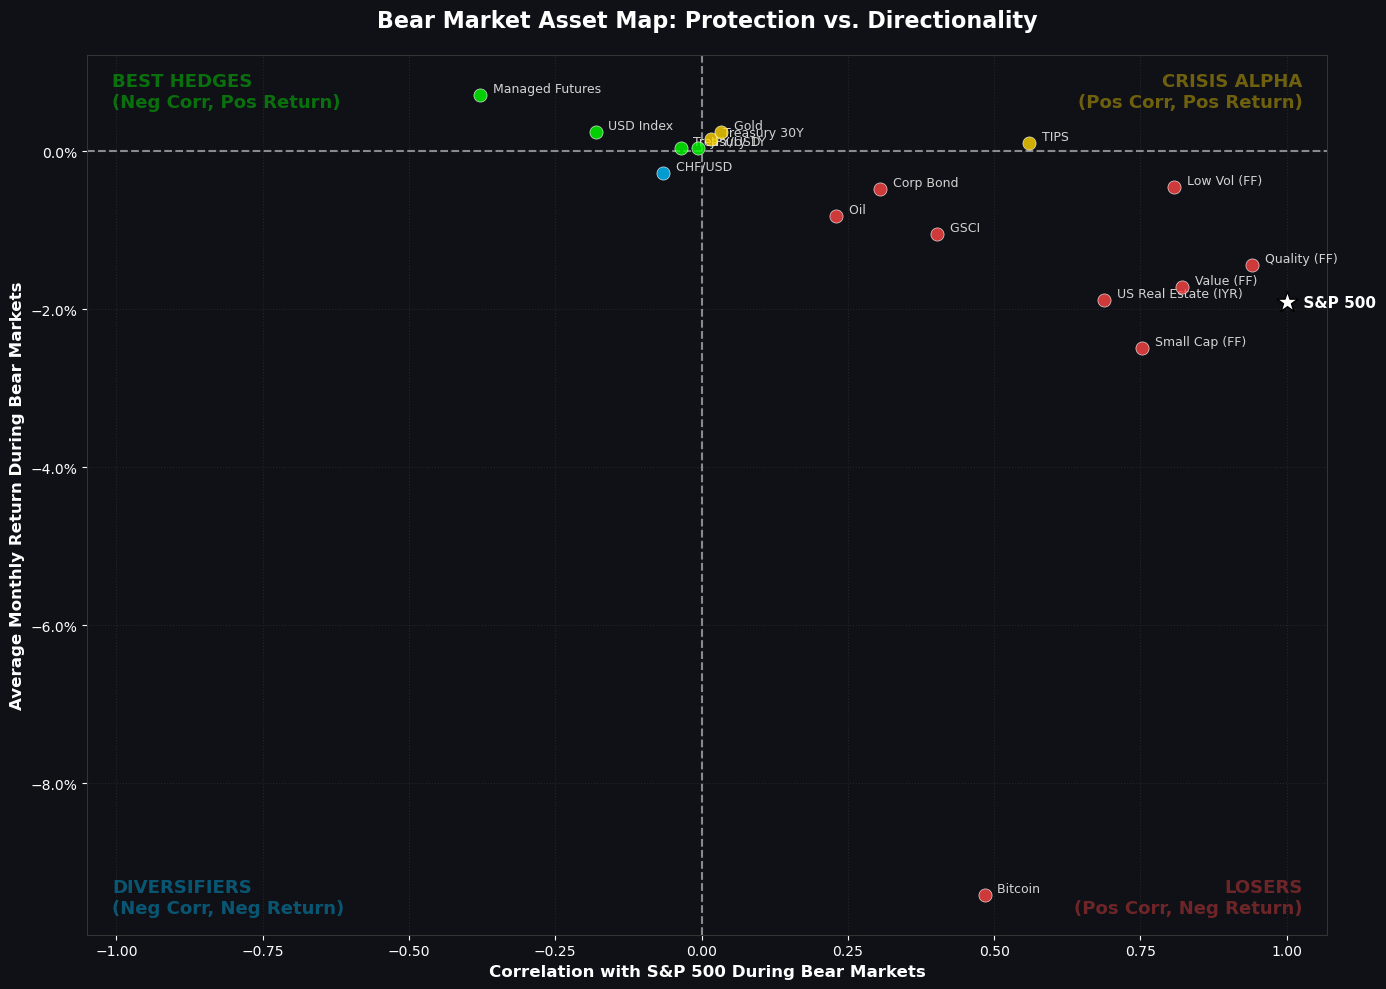

Saved visualization to: bear_market_asset_map.png


In [55]:
# In[ ]:

# ==========================================
# 8. BEAR MARKET ASSET MAP VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

print("--- Generating Bear Market Asset Map ---")

# 1. Extract Data from the performance DataFrame
# (Ensure perf_df exists from the previous cell)
plot_df = perf_df.copy()

# Drop any assets that might have completely empty bear market metrics
plot_df = plot_df.dropna(subset=["Bear Correlation", "Bear Avg Monthly Return"])

x = plot_df["Bear Correlation"]
y = plot_df["Bear Avg Monthly Return"]
labels = plot_df.index

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#0f1117")
ax.set_facecolor("#0f1117")

# 3. Draw Quadrant Axes (Crosshairs at x=0, y=0)
ax.axhline(0, color="#ffffff", linewidth=1.5, linestyle="--", alpha=0.5, zorder=2)
ax.axvline(0, color="#ffffff", linewidth=1.5, linestyle="--", alpha=0.5, zorder=2)

# 4. Plot Points & Color by Quadrant
for i, asset in enumerate(labels):
    x_val = x.iloc[i]
    y_val = y.iloc[i]
    
    # Determine color based on Quadrant
    if x_val < 0 and y_val > 0:
        color = "#00ff00"  # Green: Best Hedges (Top-Left)
    elif x_val >= 0 and y_val > 0:
        color = "#ffd700"  # Gold: Crisis Alpha (Top-Right)
    elif x_val < 0 and y_val <= 0:
        color = "#00bfff"  # Blue: Diversifiers (Bottom-Left)
    else:
        color = "#ff4444"  # Red: Losers (Bottom-Right)
        
    # Make the S&P 500 stand out as the benchmark reference point
    if asset == "S&P 500":
        ax.scatter(x_val, y_val, color="white", s=250, edgecolors="black", zorder=5, marker="*")
        ax.text(x_val + 0.02, y_val, f" {asset}", color="white", fontsize=11, fontweight="bold", va="center")
    else:
        # Standard assets
        ax.scatter(x_val, y_val, color=color, s=90, alpha=0.8, edgecolors="white", linewidth=0.5, zorder=4)
        ax.text(x_val + 0.015, y_val, f" {asset}", color="#d3d3d3", fontsize=9, va="bottom")

# 5. Dynamic Quadrant Text Labels
# Calculate axis bounds to place text nicely in the corners
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Force X-axis to show at least -1 to 1 for correlation context
x_min, x_max = min(x_min, -1.05), max(x_max, 1.05)
ax.set_xlim(x_min, x_max)

x_range = x_max - x_min
y_range = y_max - y_min

# Place Labels
ax.text(x_min + x_range*0.02, y_max - y_range*0.02, "BEST HEDGES\n(Neg Corr, Pos Return)", 
        color="#00ff00", fontsize=13, fontweight="bold", alpha=0.4, ha="left", va="top")

ax.text(x_max - x_range*0.02, y_max - y_range*0.02, "CRISIS ALPHA\n(Pos Corr, Pos Return)", 
        color="#ffd700", fontsize=13, fontweight="bold", alpha=0.4, ha="right", va="top")

ax.text(x_min + x_range*0.02, y_min + y_range*0.02, "DIVERSIFIERS\n(Neg Corr, Neg Return)", 
        color="#00bfff", fontsize=13, fontweight="bold", alpha=0.4, ha="left", va="bottom")

ax.text(x_max - x_range*0.02, y_min + y_range*0.02, "LOSERS\n(Pos Corr, Neg Return)", 
        color="#ff4444", fontsize=13, fontweight="bold", alpha=0.4, ha="right", va="bottom")

# 6. Formatting & Aesthetics
ax.set_title("Bear Market Asset Map: Protection vs. Directionality", color="white", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Correlation with S&P 500 During Bear Markets", color="white", fontsize=12, fontweight="bold")
ax.set_ylabel("Average Monthly Return During Bear Markets", color="white", fontsize=12, fontweight="bold")

# Format ticks (Make Y axis display as percentages)
ax.tick_params(colors="white", labelsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) 

for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
    
ax.grid(True, color="#333333", linestyle=":", alpha=0.6, zorder=1)

plt.tight_layout()
plt.savefig("bear_market_asset_map.png", dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()
print("Saved visualization to: bear_market_asset_map.png")